# Contact Centre Workforce Scheduling

Two problems stacked on top of each other.

**How many agents does each 15-minute interval need?** That is a queueing question, answered
by Erlang C: given the calls arriving and how long each takes to handle, how many people must
be on the phone to answer 80% of them within 20 seconds without running the floor past 85%
occupancy.

**Which named people work which shifts?** That is a combinatorial one. Sixty agents, five days,
49 intervals a day, each person carrying their own contracted hours, booked leave and start-time
accommodations. It is solved here as a mixed-integer program.

The two are linked: the Erlang layer produces a requirement curve, and the MILP tries to lay
staffed hours on top of it without over- or under-shooting.

All data is synthetic and seeded. No real call volumes, no real employees.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

# make the package importable whether this runs from notebooks/ or the repo root
root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd

from src.erlang import ServiceTarget, erlang_c, required_agents, service_level, traffic_intensity
from src.generator import build_shift_templates, capacity_report, generate_demand, generate_roster, roster_summary
from src.optimizer import coverage_lower_bound, hours_frame, solve_schedule
from src.reporting import plot_coverage, plot_shift_gantt, plot_week_coverage

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
SEED = 42

## 1. Demand

A bimodal intraday curve: a late-morning peak, a softer mid-afternoon one, Monday heavy and
Friday light. Handle times vary around a 320-second mean.

In [2]:
demand = generate_demand(seed=SEED)
demand.head(8)

,day,day_name,interval,time,calls,aht_sec,erlangs,required_agents
0,0,Mon,0,07:00,6.0,321.5,2.14,4
1,0,Mon,1,07:15,7.0,326.4,2.54,5
2,0,Mon,2,07:30,15.0,333.9,5.56,9
3,0,Mon,3,07:45,21.0,287.9,6.72,10
4,0,Mon,4,08:00,23.0,313.0,8.00,12
5,0,Mon,5,08:15,34.0,309.7,11.70,16
6,0,Mon,6,08:30,48.0,305.9,16.32,21
7,0,Mon,7,08:45,60.0,313.9,20.93,26


In [3]:
demand.groupby("day_name", sort=False).agg(
    calls=("calls", "sum"),
    peak_calls=("calls", "max"),
    mean_aht=("aht_sec", "mean"),
    peak_required=("required_agents", "max"),
    agent_intervals=("required_agents", "sum"),
).round(1)

,calls,peak_calls,mean_aht,peak_required,agent_intervals
day_name,,,,,
Mon,3293.0,127.0,316.0,55,1423
Tue,2985.0,114.0,321.1,53,1308
Wed,2835.0,111.0,321.2,45,1247
Thu,2748.0,107.0,320.8,46,1221
Fri,2404.0,92.0,323.4,44,1088


## 2. Erlang C sizing

Offered load in Erlangs is `calls × AHT / 900`. The queueing model turns that into a headcount
by asking, for each candidate number of agents, what fraction of calls would be answered inside
the target time.

The usual textbook formula is written with factorials and overflows a float above roughly
135 Erlangs, because `A^N` blows up long before the ratio does. `src/erlang.py` uses the
Erlang B recursion instead, which never forms that term. Same answer, no ceiling.

In [4]:
target = ServiceTarget(service_level=0.80, target_time_sec=20.0, max_occupancy=0.85)

rows = []
for calls in [10, 25, 50, 75, 100, 150, 200]:
    intensity = traffic_intensity(calls, 320)
    agents = required_agents(calls, 320, target)
    rows.append({
        "calls_per_interval": calls,
        "erlangs": round(intensity, 1),
        "required_agents": agents,
        "service_level": round(service_level(agents, calls, 320), 3),
        "occupancy": round(intensity / agents, 3),
        "sl_at_one_fewer": round(service_level(agents - 1, calls, 320), 3),
    })
pd.DataFrame(rows)

,calls_per_interval,erlangs,required_agents,service_level,occupancy,sl_at_one_fewer
0,10,3.6,6,0.839,0.593,0.638
1,25,8.9,13,0.887,0.684,0.795
2,50,17.8,22,0.805,0.808,0.702
3,75,26.7,32,0.831,0.833,0.755
4,100,35.6,42,0.856,0.847,0.799
5,150,53.3,63,0.925,0.847,0.898
6,200,71.1,84,0.959,0.847,0.945


Note which constraint bites where. At low volume the service level is what forces headcount up
and occupancy sits comfortably below the cap. At high volume the queue enjoys economies of
scale — it hits 80/20 while still running agents at 89% — and the occupancy cap becomes the
binding constraint. Drop the cap and you get staffing numbers that satisfy the SLA and burn
the floor out.

## 3. Roster and shift templates

Shifts are chosen from a set of legal templates rather than assembled from free per-interval
booleans. Unconstrained interval variables produce mathematically optimal, operationally absurd
rosters where somebody works 07:00–07:15 and again at 16:45.

Each template carries two different quantities, and conflating them is the classic way to build
a roster that looks compliant and still leaves the queue unmanned at 12:30:

- **paid hours** — what the agent is paid for, excluding the unpaid meal break
- **coverage** — the intervals they are actually on the phone, excluding meal *and* rest breaks

In [5]:
templates = build_shift_templates(step=2)
agents = generate_roster(seed=SEED)

pd.DataFrame([{
    "id": t.id,
    "kind": t.kind,
    "window": t.label(),
    "on_site_intervals": t.span,
    "paid_hours": t.paid_hours,
    "on_phone_intervals": t.covered_intervals,
    "break_intervals": len(t.breaks),
} for t in templates]).head(10)

,id,kind,window,on_site_intervals,paid_hours,on_phone_intervals,break_intervals
0,FT8_0700,full_time,07:00-15:30,34,8.0,30,4
1,FT8_0730,full_time,07:30-16:00,34,8.0,30,4
2,FT8_0800,full_time,08:00-16:30,34,8.0,30,4
3,FT8_0830,full_time,08:30-17:00,34,8.0,30,4
4,FT8_0900,full_time,09:00-17:30,34,8.0,30,4
5,FT8_0930,full_time,09:30-18:00,34,8.0,30,4
6,FT8_1000,full_time,10:00-18:30,34,8.0,30,4
7,FT8_1030,full_time,10:30-19:00,34,8.0,30,4
8,PT6_0700,part_time,07:00-13:30,26,6.0,22,4
9,PT6_0730,part_time,07:30-14:00,26,6.0,22,4


In [6]:
summary = roster_summary(agents)
print(f"{len(agents)} agents | {len(templates)} shift templates")
print(summary.kind.value_counts().to_string())
print(f"\naccommodations: {(summary.accommodation != '-').sum()}")
print(f"agents with booked leave: {(summary.blackout_intervals > 0).sum()}")
print(f"total blacked-out intervals: {summary.blackout_intervals.sum()}")
summary[summary.accommodation != "-"].head()

60 agents | 37 shift templates
kind
full_time    45
part_time    15

accommodations: 4
agents with booked leave: 40
total blacked-out intervals: 487


,agent,kind,min_weekly_hours,max_weekly_hours,accommodation,blackout_intervals
0,AGT-001,full_time,32.0,40.0,must start by 09:00,8
18,AGT-019,full_time,32.0,37.5,must start by 09:00,21
48,AGT-049,part_time,8.0,20.0,cannot start before 10:00,0
55,AGT-056,part_time,8.0,24.0,cannot start before 10:00,0


## 4. Can this roster even cover the week?

Worth asking before the solver runs. If contracted hours cannot cover demand, the MILP will
still return a schedule — it will just be an understaffed one — and knowing that in advance
stops you blaming the optimiser for an establishment problem.

In [7]:
capacity = capacity_report(agents, templates, demand)
for key, value in capacity.items():
    print(f"{key:38s} {value}")

required_agent_intervals               6287
supply_ceiling_agent_intervals         7796
utilisation_of_ceiling                 0.806
contracted_minimum_intervals           6240
demand_exceeds_ceiling                 False
minimum_hours_exceed_demand            False


## 5. A lower bound before optimising

Solve the same coverage problem with agents treated as interchangeable — decide only *how many*
of each template run each day, with no identities, no leave, no accommodations. That relaxation
solves in under a second and bounds what any real schedule can achieve.

The gap between this bound and the full solve is the price of the workforce being made of
specific people rather than of interchangeable labour. Without it you cannot tell "the demand
curve is hard to staff" from "this particular roster cannot staff it".

In [8]:
bound = coverage_lower_bound(agents, templates, demand)
bound

{'status': 'Optimal',
 'solve_seconds': 0.67,
 'min_understaffed_agent_intervals': 40,
 'min_overstaffed_agent_intervals': 905,
 'shifts_required': 297}

## 6. The assignment model

    x[i, d, s] ∈ {0,1}   agent i works template s on day d
    under[d, t] ≥ 0      agents short of the requirement
    over[d, t]  ≥ 0      agents surplus to it
    short[i]    ≥ 0      hours below agent i's contracted minimum

    minimise  100·Σ under  +  1·Σ over  +  50·Σ short·4

Understaffing is the thing being avoided, so it is priced a hundred times a surplus agent.
Breaching a contracted minimum sits between the two.

Two deliberate departures from the textbook formulation:

**Availability is structural, not a constraint.** A variable only exists where the agent could
legally work that template, so leave and accommodations shrink the model instead of adding rows.

**The weekly minimum is soft; the maximum is hard.** A hard minimum combined with leave and
accommodations makes the model infeasible for reasons that have nothing to do with scheduling,
and an infeasible solve tells you nothing. Priced at 50 it still dominates surplus staffing, so
the solver only breaches a minimum when nothing else works — and then it reports who and by how much.

In [9]:
schedule = solve_schedule(agents, templates, demand, time_limit_sec=180, gap=0.03)

for key, value in schedule.summary().items():
    print(f"{key:36s} {value}")

status                               Optimal
solve_seconds                        51.32
binary_variables                     8850
shifts_assigned                      293
scheduled_hours                      1924.0
understaffed_intervals               11
understaffed_agent_intervals         50
understaffed_hours                   12.5
overstaffed_agent_intervals          952
intervals_fully_covered              234
coverage_compliance_pct              95.5
agents_below_contracted_minimum      0


### Where the residual understaffing comes from

With the relaxation bound in hand the shortfall splits into two parts with different remedies.
Structural shortfall is a demand-curve problem — it needs different shift shapes or more
establishment. Availability shortfall is a roster problem — different leave approvals would
move it.

In [10]:
total_short = schedule.summary()["understaffed_agent_intervals"]
structural = bound["min_understaffed_agent_intervals"]

print(f"total understaffed agent-intervals   {total_short}")
print(f"  inherent to the demand curve       {structural}")
print(f"  caused by individual availability  {total_short - structural}")
print(f"\nas hours: {total_short * 0.25:.2f}h short across a week of {int(demand.required_agents.sum()) * 0.25:.0f} required agent-hours")

total understaffed agent-intervals   50
  inherent to the demand curve       40
  caused by individual availability  10

as hours: 12.50h short across a week of 1572 required agent-hours


## 7. Coverage

The scheduled bars against the Erlang C requirement. Pink is where the schedule falls short.

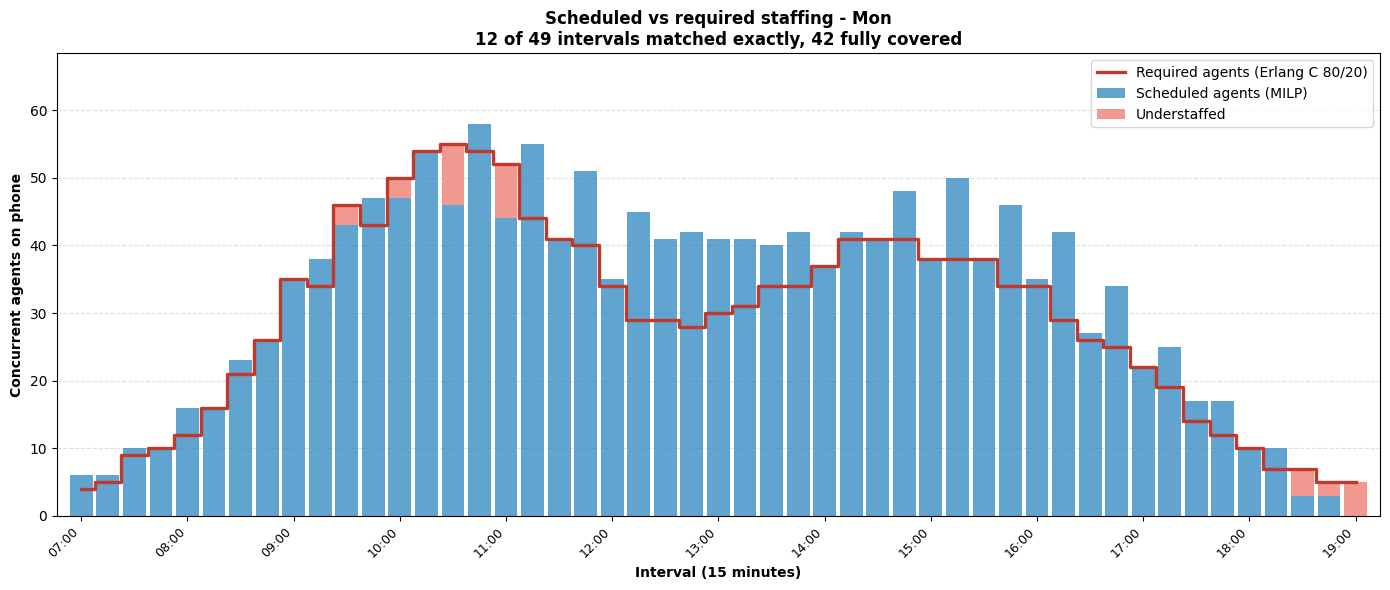

In [11]:
_ = plot_coverage(schedule, day=0, save_path=root / "assets" / "coverage_vs_requirement.png")

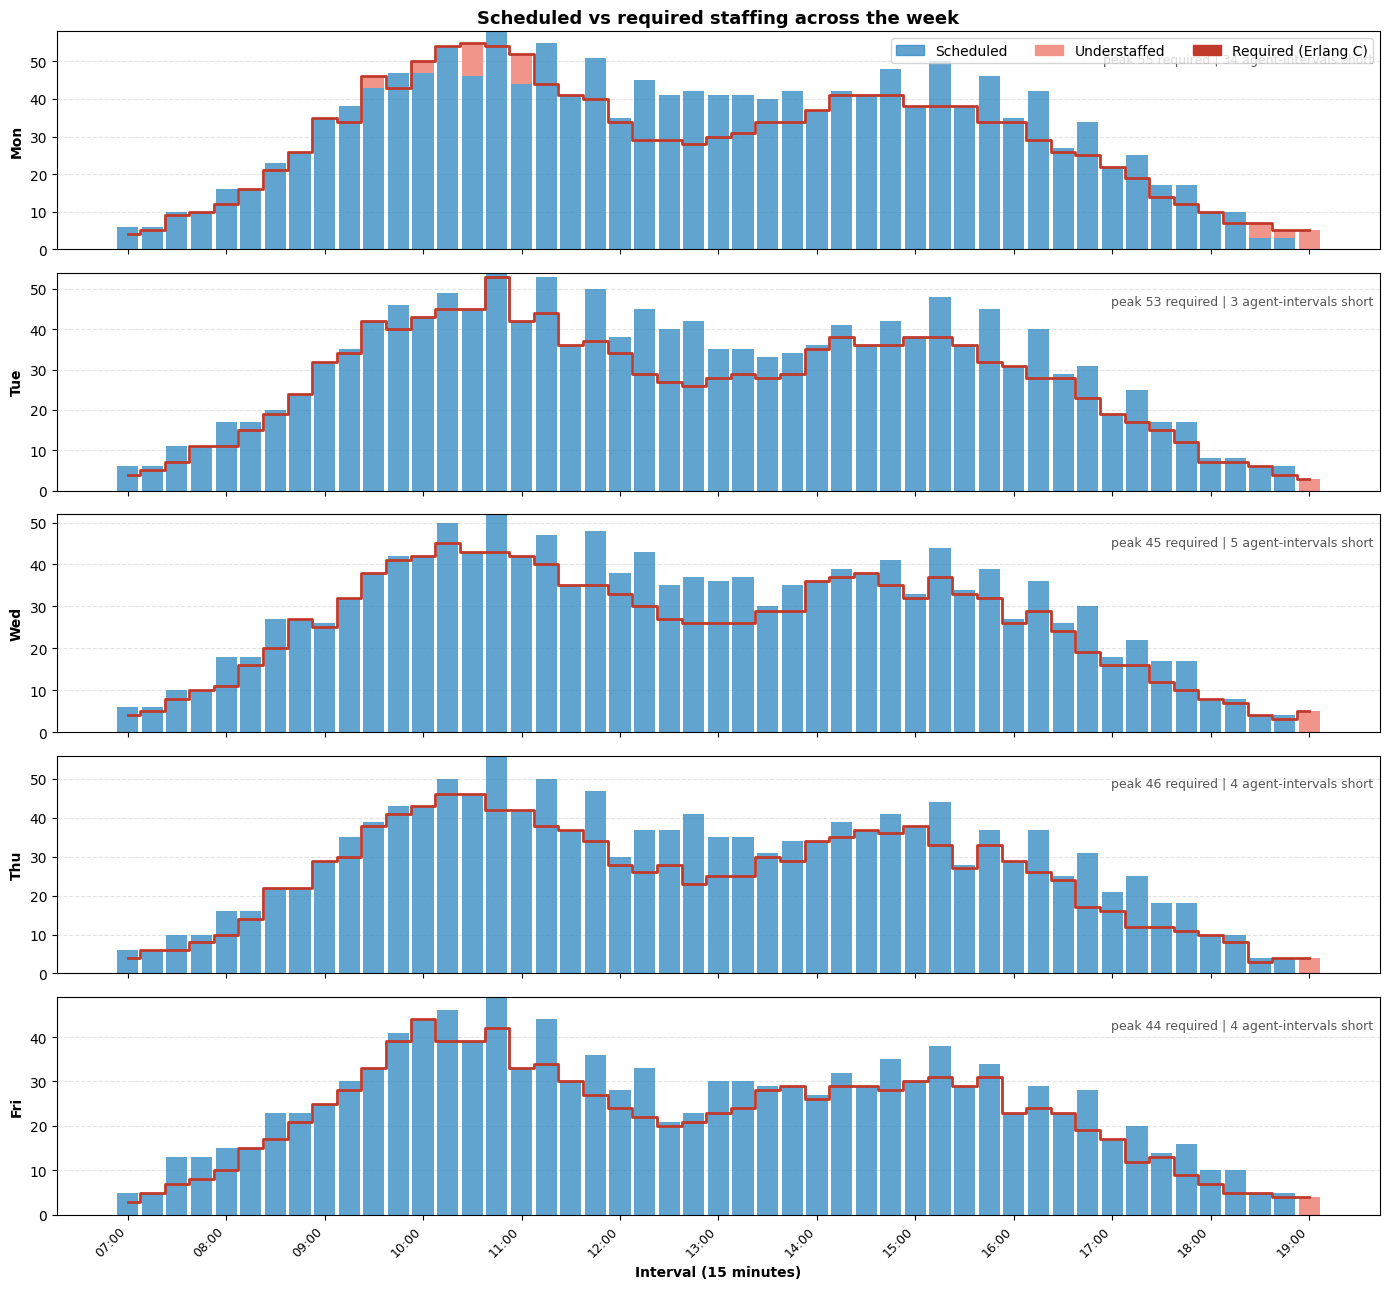

In [12]:
_ = plot_week_coverage(schedule, save_path=root / "assets" / "coverage_week.png")

## 8. What each agent actually does

Aggregate coverage can look right while the per-agent plan is unworkable, so it is worth
looking at the shifts themselves. The staggered starts the optimiser chose show up as a diagonal.

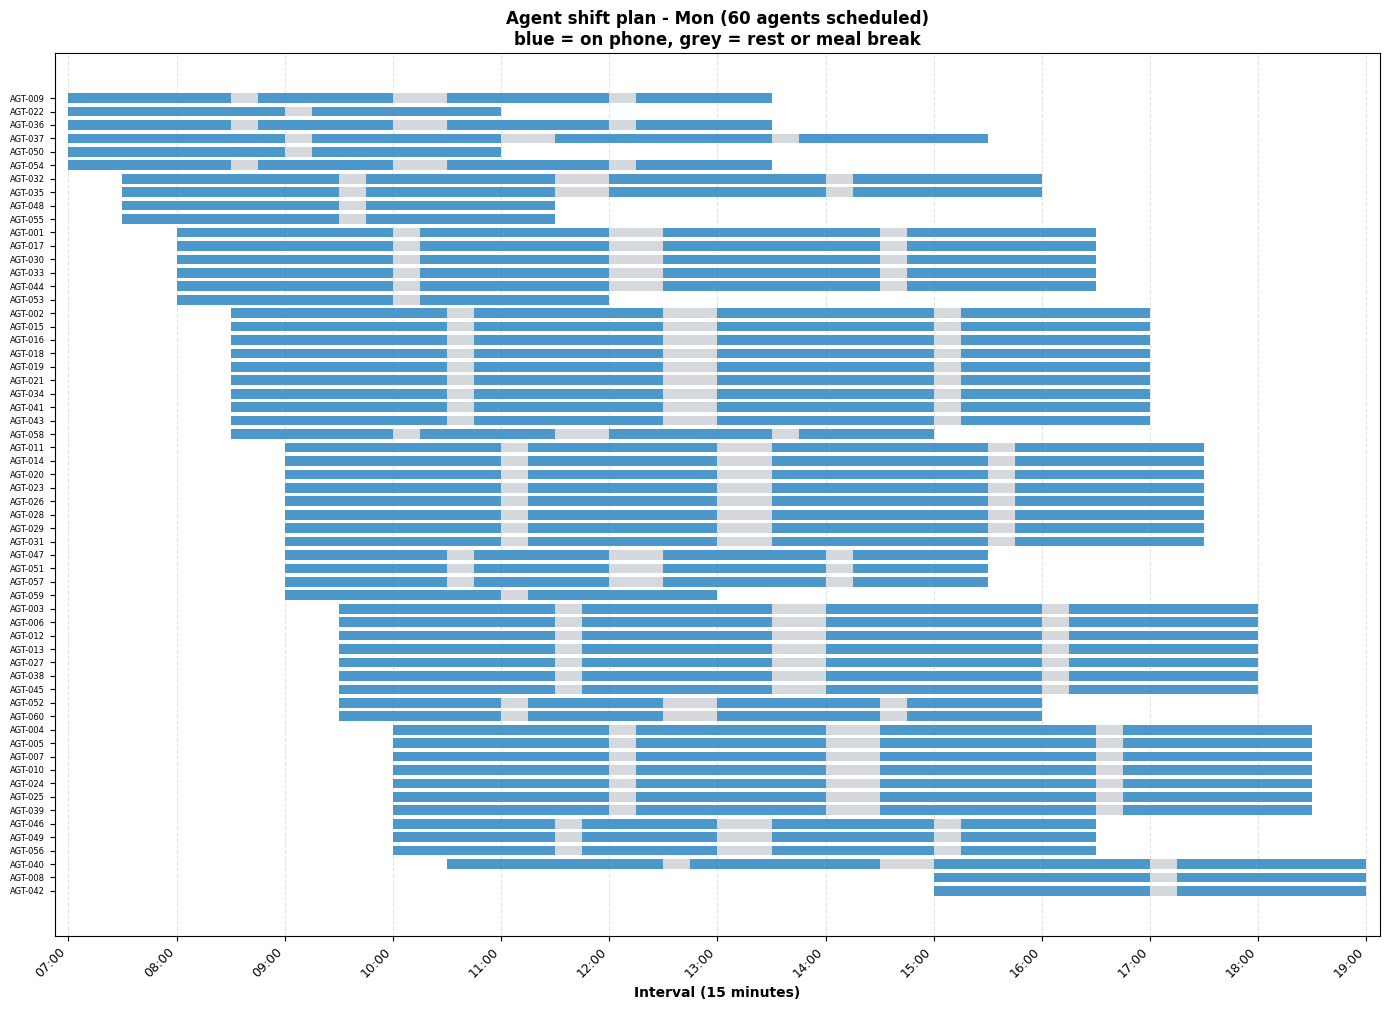

In [13]:
_ = plot_shift_gantt(schedule, day=0, save_path=root / "assets" / "shift_gantt.png")

In [14]:
schedule.to_frame().head(12)

,agent,day,shift,start,end,paid_hours,on_phone_intervals
0,AGT-001,Mon,FT8_0800,08:00,16:30,8.0,30
1,AGT-001,Tue,PT4_0700,07:00,11:00,4.0,15
2,AGT-001,Wed,FT8_0730,07:30,16:00,8.0,30
3,AGT-001,Thu,FT8_0900,09:00,17:30,8.0,30
4,AGT-001,Fri,PT6_0900,09:00,15:30,6.0,22
5,AGT-002,Mon,FT8_0830,08:30,17:00,8.0,30
6,AGT-002,Tue,PT4_1500,15:00,19:00,4.0,15
7,AGT-002,Wed,FT8_0830,08:30,17:00,8.0,30
8,AGT-002,Thu,PT4_1430,14:30,18:30,4.0,15
9,AGT-002,Fri,FT8_0830,08:30,17:00,8.0,30


## 9. Checking the constraints actually held

An optimiser will happily return a schedule that violates something you forgot to encode.
These assertions re-derive the constraints from the assignments rather than trusting the model.

In [15]:
by_id = {a.id: a for a in agents}
problems = []

seen = set()
for assignment in schedule.assignments:
    key = (assignment.agent_id, assignment.day)
    if key in seen:
        problems.append(f"{assignment.agent_name} double-booked on day {assignment.day}")
    seen.add(key)

for agent_id, hours in schedule.agent_hours.items():
    if hours > by_id[agent_id].max_weekly_hours + 1e-6:
        problems.append(f"{by_id[agent_id].name} over contracted maximum: {hours}h")

for assignment in schedule.assignments:
    agent = by_id[assignment.agent_id]
    if any(assignment.template.occupies(i) for i in agent.blackouts.get(assignment.day, set())):
        problems.append(f"{agent.name} scheduled during booked leave on day {assignment.day}")
    if not (agent.earliest_start <= assignment.template.start <= agent.latest_start):
        problems.append(f"{agent.name} start-window accommodation breached")
    if agent.kind == "part_time" and assignment.template.kind == "full_time":
        problems.append(f"{agent.name} is part-time but got a full-time shift")

rebuilt = np.zeros_like(schedule.coverage)
for assignment in schedule.assignments:
    rebuilt[assignment.day] += np.array(assignment.template.coverage, dtype=int)
if not np.array_equal(rebuilt, schedule.coverage):
    problems.append("reported coverage does not match the assignments")

print("\n".join(problems) if problems else "All constraints hold.")

All constraints hold.


## 10. Hours delivered against hours contracted

In [16]:
hours = hours_frame(schedule, agents)
print(hours.groupby("kind").agg(
    agents=("agent", "count"),
    contracted_min=("min_hours", "sum"),
    contracted_max=("max_hours", "sum"),
    scheduled=("scheduled_hours", "sum"),
    shortfall=("shortfall", "sum"),
).round(1).to_string())

below = hours[hours.shortfall > 0]
print(f"\nagents below their contracted minimum: {len(below)}")
below.head()

           agents  contracted_min  contracted_max  scheduled  shortfall
kind                                                                   
full_time      45          1440.0          1755.0     1600.0        0.0
part_time      15           120.0           324.0      324.0        0.0

agents below their contracted minimum: 0


,agent,kind,min_hours,max_hours,scheduled_hours,shortfall,shifts,accommodation


## What this does not do

- **Shrinkage is modelled explicitly, not as a percentage uplift.** Breaks are carved out of the
  coverage vectors rather than added as a blanket factor. Unplanned absence and adherence are
  not modelled at all, so real-world coverage would run below what is shown here.
- **Demand is deterministic.** Each interval takes its expected call volume. A real forecast
  carries error, and a schedule optimised against a point estimate is fragile to it.
- **Erlang C assumes no abandonment and infinite queue patience.** Erlang A is the model that
  relaxes that, and it usually reduces required headcount.
- **Intervals are treated independently.** Erlang C is a steady-state model; calls queueing at
  10:15 and still waiting at 10:30 are not carried across.
- **Optimality is not proven.** With 60 largely interchangeable agents the model is highly
  symmetric, so the search stops at a 3% relative gap. The relaxation bound above is the honest
  measure of how much is left on the table.